In [2]:
import os

os.listdir()

['.config', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'sample_data']

# Business Analytics Case Study: Telco Customer Churn Analysis

## Step 1: Importing Libraries

In this step, we import the Python libraries required for data analysis and visualization.

- **Pandas** will be used to load, clean, and manipulate the dataset.
- **NumPy** will help with numerical computations.
- **Matplotlib** will be used to create basic charts and graphs.
- **Seaborn** will be used to generate attractive statistical visualizations.

These libraries provide the tools needed to explore the data and uncover business insights.

In [3]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Improve the appearance of plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

### Observation

The required Python libraries were imported successfully without any errors.

These libraries will be used throughout the project for data loading, data cleaning, exploratory data analysis (EDA), and visualization. Successfully importing them confirms that the analysis environment is ready.

# Step 2: Loading the Dataset

## Purpose

Before we can analyze customer churn, we need to load the dataset into Python.

The dataset is stored as a CSV (Comma-Separated Values) file. Using the Pandas library, we will load it into a DataFrame, which is a tabular data structure that makes it easy to view, clean, manipulate, and analyze data.

After loading the dataset, we will display the first five records to verify that it has been imported successfully.

In [4]:
# Load the dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first five rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Observation

The dataset was loaded successfully into a Pandas DataFrame.

Displaying the first five rows confirms that the data has been imported correctly. The dataset contains customer demographic information, subscribed services, billing details, contract information, and the target variable **Churn**, which indicates whether a customer left the company.

This initial preview helps us understand the structure of the dataset before performing further exploration and analysis.

# Step 3: Exploring the Dataset

## Purpose

Before performing any analysis, it is important to understand the overall structure of the dataset.

In this section, we will examine:

- The number of rows and columns.
- The names of the variables.
- The data types of each variable.
- Whether there are any missing values.
- Basic summary statistics.

Understanding the dataset helps us identify potential data quality issues and determine the appropriate analysis techniques to apply in later stages.

In [5]:
# Display the number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


### Observation

The dataset contains **7,043 customer records** and **21 variables**.

Each row represents a unique customer, while each column contains information describing customer demographics, subscribed services, billing details, contract information, and whether the customer churned.

The dataset size is sufficient to perform meaningful business analytics and identify customer behavior patterns.

In [6]:
# Display all column names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Observation

The dataset contains **21 variables** describing different aspects of each customer.

These variables include demographic information, services subscribed, billing details, payment methods, contract types, and the target variable **Churn**.

Having a diverse set of variables allows us to investigate multiple factors that may influence customer churn.

## Step 3.1: Examining the Dataset Structure

### Purpose

Before performing any analysis, it is important to understand the structure of the dataset.

In this step, we will examine:

- The data type of each variable.
- The number of non-null values.
- The total number of columns.
- The memory usage of the dataset.

Understanding the dataset structure helps identify variables that may require cleaning or conversion before analysis.

In [7]:
# Display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Observation

The dataset contains **7,043 records** and **21 variables**.

Most variables have appropriate data types. Categorical variables such as **gender**, **Contract**, and **PaymentMethod** are stored as text (`object`), while numerical variables such as **tenure** and **MonthlyCharges** are stored as integers and floating-point numbers.

However, the **TotalCharges** column is stored as an `object` instead of a numeric data type. Since total charges represent monetary values, this suggests that the column may contain non-numeric or blank values that need to be investigated during the data cleaning phase.

# Step 4: Data Cleaning

## Purpose

Real-world datasets often contain inconsistencies, incorrect data types, duplicate records, or missing values that can affect the accuracy of the analysis.

In this section, we will inspect the dataset for data quality issues and clean it to ensure it is suitable for business analytics.

The cleaning process includes:

- Checking for missing values.
- Identifying duplicate records.
- Correcting data types.
- Preparing the dataset for exploratory data analysis (EDA).

In [8]:
# Check for missing values

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Observation

The initial missing value assessment indicates that there are no null (`NaN`) values in the dataset.

However, this does not necessarily mean that the data is completely clean. Some columns, particularly **TotalCharges**, may contain blank strings rather than true null values. These hidden missing values require additional investigation before analysis.

## Step 4.1: Investigating the TotalCharges Column

### Purpose

The initial missing value assessment showed no null values in the dataset. However, the **TotalCharges** column is stored as a text (`object`) data type instead of a numeric type.

This suggests that the column may contain hidden blank values or non-numeric characters.

In this step, we will identify these hidden values before converting the column into a numeric data type.

In [9]:
# Count blank values in the TotalCharges column

(df['TotalCharges'] == " ").sum()

np.int64(11)

### Observation

Although the initial missing value assessment showed no null (`NaN`) values, further investigation revealed that the **TotalCharges** column contains **11 blank string values**.

These blank values are hidden missing values that prevent the column from being treated as a numeric variable.

This issue is likely caused by customers who have recently joined the company and have not yet accumulated any total charges.

The **TotalCharges** column will need to be converted to a numeric data type, with blank values handled appropriately before further analysis.

## Step 4.2: Converting the TotalCharges Column to Numeric

### Purpose

The **TotalCharges** column is currently stored as a text (`object`) data type because it contains blank string values.

To perform numerical analysis, we need to convert this column into a numeric format.

During the conversion, any non-numeric values will automatically be converted into `NaN` (missing values), allowing us to identify and handle them correctly.

In [10]:
# Convert TotalCharges to numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check the data type

print(df['TotalCharges'].dtype)

# Count the missing values after conversion

print(df['TotalCharges'].isnull().sum())

float64
11


### Observation

The **TotalCharges** column was successfully converted from a text (`object`) data type to a numeric (`float64`) data type.

During the conversion, the 11 blank string values were automatically converted into proper missing values (`NaN`).

Since these missing values represent only a very small proportion of the dataset (11 out of 7,043 records), removing these records is a reasonable approach that is unlikely to affect the overall analysis.

## Step 4.3: Handling Missing Values

### Purpose

After converting the **TotalCharges** column to a numeric data type, the hidden blank values became visible as missing values (`NaN`).

Since only **11 records** are affected, representing less than **0.2%** of the dataset, these records will be removed to ensure a clean and reliable dataset for analysis.

In [11]:
# Remove rows with missing values

df = df.dropna()

# Verify that all missing values have been removed

print(df.isnull().sum())

# Display the new shape of the dataset

print("\nNew Dataset Shape:", df.shape)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

New Dataset Shape: (7032, 21)


### Observation

The missing values in the **TotalCharges** column were successfully removed.

The dataset now contains **7,032 customer records** and **21 variables**, with no remaining missing values.

Since only **11 records (0.16%)** were removed, the integrity of the dataset has been preserved, making it suitable for further analysis.

## Step 4.4: Checking for Duplicate Records

### Purpose

Duplicate records can distort analysis by counting the same customer more than once.

In this step, we will check whether the dataset contains duplicate rows. If duplicates exist, they will be removed to ensure that each customer is represented only once in the analysis.

In [12]:
# Check for duplicate rows

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


### Observation

The duplicate record assessment revealed that the dataset contains **no duplicate rows**.

This indicates that each customer is represented only once in the dataset, ensuring that the analysis will not be affected by repeated records.

With no duplicate records and no remaining missing values, the dataset is now clean and ready for exploratory data analysis (EDA).

# Step 5: Exploratory Data Analysis (EDA)

## Analysis 1: Customer Churn Distribution

### Purpose

Before investigating the factors influencing customer churn, it is important to understand the overall distribution of customers who stayed and those who left.

This analysis provides an overview of the company's customer retention performance and establishes the foundation for further investigation into the drivers of churn.

In [13]:
# Count customers by churn status

df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [14]:
# Calculate churn percentages

churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


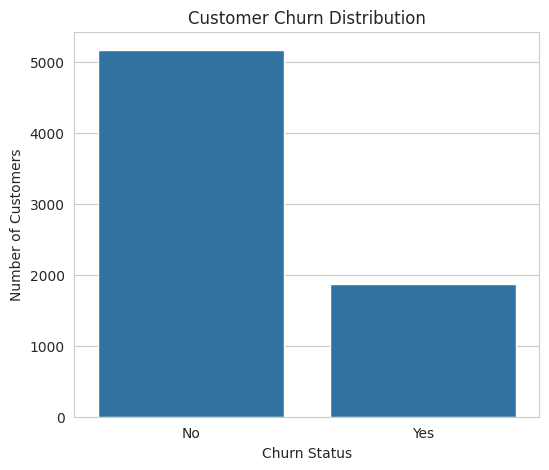

In [15]:
# Create a bar chart of customer churn

plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')

plt.xlabel('Churn Status')

plt.ylabel('Number of Customers')

plt.show()

### Observation

The customer churn distribution shows that the majority of customers remained with the company, while a substantial proportion left.

Approximately **73%** of customers did not churn, whereas **27%** discontinued the company's services.

Although customer retention is relatively high, losing more than one-quarter of customers represents a significant business challenge. This highlights the importance of identifying the factors contributing to churn and developing effective customer retention strategies.

# Analysis 2: Customer Churn by Contract Type

## Business Question

Does the type of customer contract influence the likelihood of customer churn?

Contract type is an important business factor because customers with longer-term contracts may be more committed to the company's services, while customers on shorter contracts may have greater flexibility to switch to competitors.

This analysis investigates the relationship between contract type and customer churn.

In [16]:
# Number of customers by contract type

df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1685
One year,1472


In [17]:
# Contract type versus churn

contract_churn = pd.crosstab(df['Contract'], df['Churn'])

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


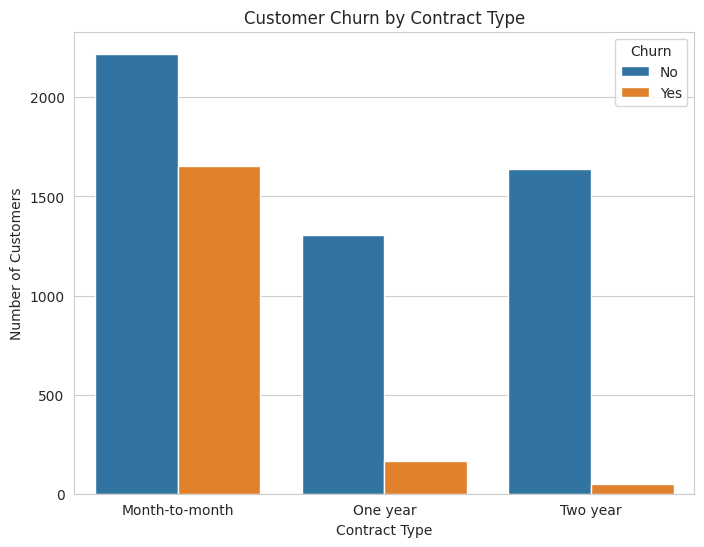

In [18]:
# Churn by contract type

plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The analysis reveals a strong relationship between **contract type** and **customer churn**.

Customers on **month-to-month contracts** recorded the highest number of churn cases (**1,655 customers**), whereas customers on **one-year** and **two-year contracts** experienced substantially lower churn.

This suggests that customers with long-term contracts are more likely to remain with the company, while customers with short-term contracts have greater flexibility to switch to competitors.

Contract type appears to be one of the strongest factors influencing customer retention in the dataset.

# Analysis 3: Monthly Charges vs Customer Churn

## Business Question

Does the amount a customer pays each month influence their likelihood of leaving the company?

Monthly charges are an important business metric because customers who perceive the service as too expensive may be more likely to switch to competitors offering better pricing or value.

This analysis compares the monthly charges of customers who stayed with those who churned.

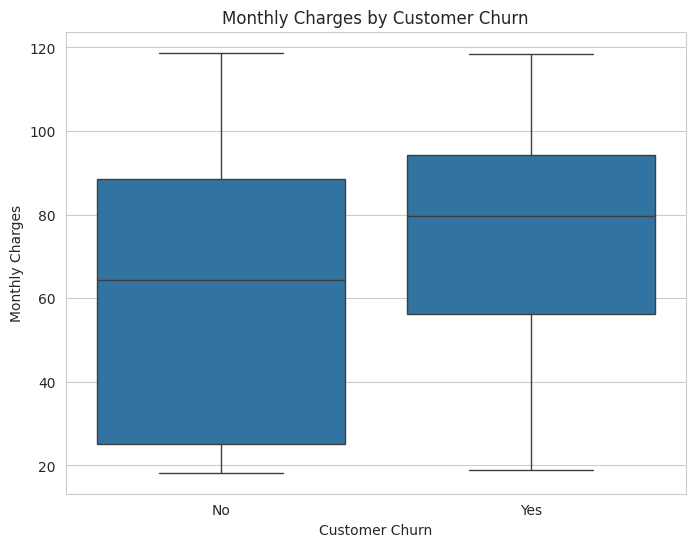

In [19]:
# Box plot of Monthly Charges by Churn

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title("Monthly Charges by Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [20]:
# Average monthly charges by churn status

df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.307408
Yes,74.441332


### Observation

The analysis shows that customers who churned paid **higher average monthly charges (74.44)** compared to customers who remained with the company (**61.31**).

The box plot also indicates that the distribution of monthly charges is generally higher among customers who churned.

This suggests that higher monthly charges may contribute to customer dissatisfaction and increase the likelihood of churn. However, pricing alone may not fully explain customer behavior, and additional factors should also be considered.

# Analysis 4: Customer Tenure vs Churn

## Business Question

Does the length of time a customer has been with the company influence their likelihood of churning?

Customer tenure is an important indicator of loyalty. Customers with longer relationships may be more satisfied and less likely to leave, while newer customers may still be evaluating the company's services and could be more likely to switch providers.

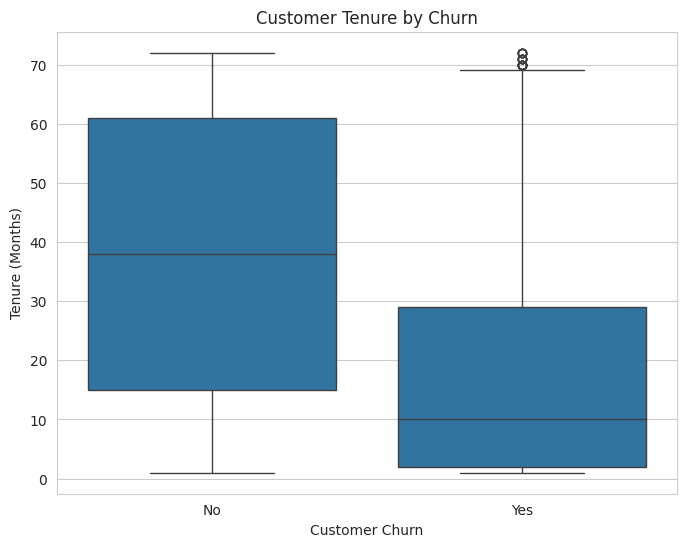

In [21]:
# Box plot of Tenure by Churn

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title("Customer Tenure by Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [22]:
# Average tenure by churn status

df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


### Observation

The analysis indicates a strong relationship between **customer tenure** and **customer churn**.

Customers who remained with the company had an average tenure of **37.65 months**, whereas customers who churned had an average tenure of only **17.98 months**.

The box plot further shows that customers who churn generally have shorter tenures than those who remain.

These findings suggest that newer customers are significantly more likely to leave the company, while long-term customers demonstrate greater loyalty and retention.

# Analysis 5: Internet Service vs Customer Churn

## Business Question

Does the type of internet service subscribed to by a customer influence their likelihood of churning?

Different internet technologies provide different customer experiences in terms of speed, reliability, and pricing. Understanding the relationship between internet service type and customer churn can help the company improve service quality and customer retention.

In [23]:
# Internet Service vs Churn

internet_churn = pd.crosstab(df['InternetService'], df['Churn'])

internet_churn

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


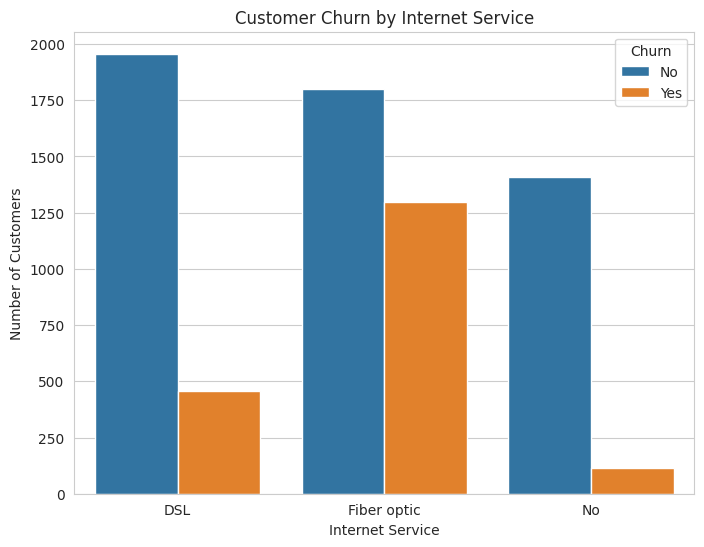

In [24]:
# Churn by Internet Service

plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn'
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The analysis indicates that customers using **Fiber optic** internet services recorded the highest number of churn cases (**1,297 customers**) compared to customers using **DSL** or those without internet service.

Customers with **No Internet Service** experienced the lowest level of churn, while DSL customers also demonstrated relatively better retention.

These findings suggest that Fiber optic customers are more likely to discontinue the company's services, indicating that this customer segment may require targeted retention strategies and further investigation into service quality, pricing, or customer satisfaction.

# Analysis 6: Payment Method vs Customer Churn

## Business Question

Does the method a customer uses to pay for their services influence their likelihood of churning?

Understanding the relationship between payment methods and customer churn can help the company identify whether certain payment options are associated with higher customer retention or increased churn.

In [25]:
# Payment Method vs Churn

payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'])

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


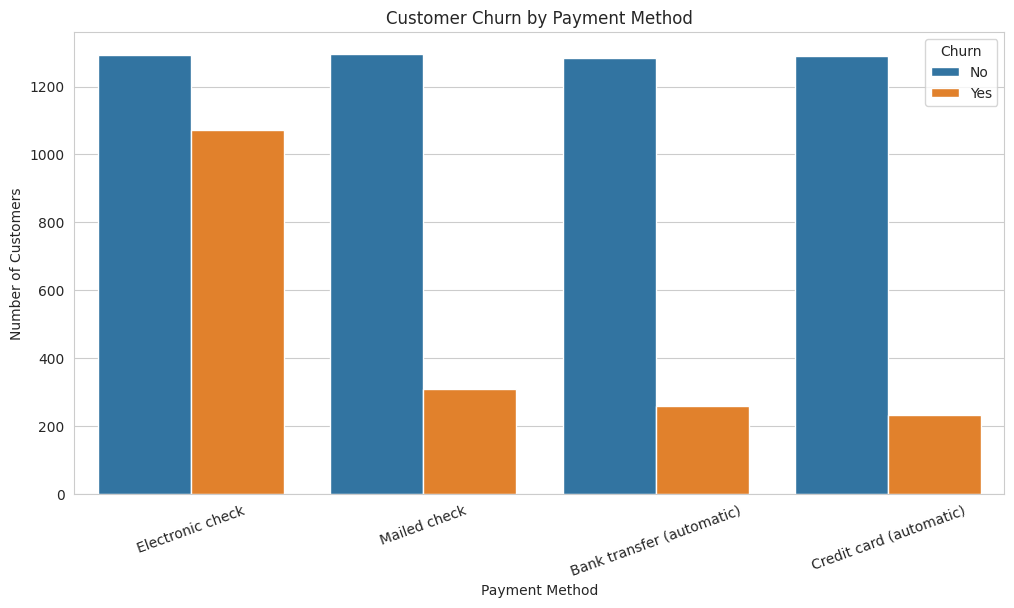

In [26]:
# Customer Churn by Payment Method

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn'
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

### Observation

The analysis reveals that customers using **Electronic check** as their payment method recorded the highest number of churn cases (**1,071 customers**).

In contrast, customers using **automatic payment methods**, such as **Bank transfer (automatic)** and **Credit card (automatic)**, experienced substantially lower churn.

This suggests that payment convenience may influence customer retention. Encouraging customers to adopt automatic payment methods could potentially reduce customer churn.

# Analysis 7: Technical Support vs Customer Churn

## Business Question

Does access to technical support influence customer churn?

Technical support plays an important role in resolving customer issues and improving satisfaction. This analysis investigates whether customers who receive technical support are more likely to remain with the company than those who do not.

In [27]:
# Technical Support vs Churn

techsupport_churn = pd.crosstab(df['TechSupport'], df['Churn'])

techsupport_churn

Churn,No,Yes
TechSupport,,
No,2026,1446
No internet service,1407,113
Yes,1730,310


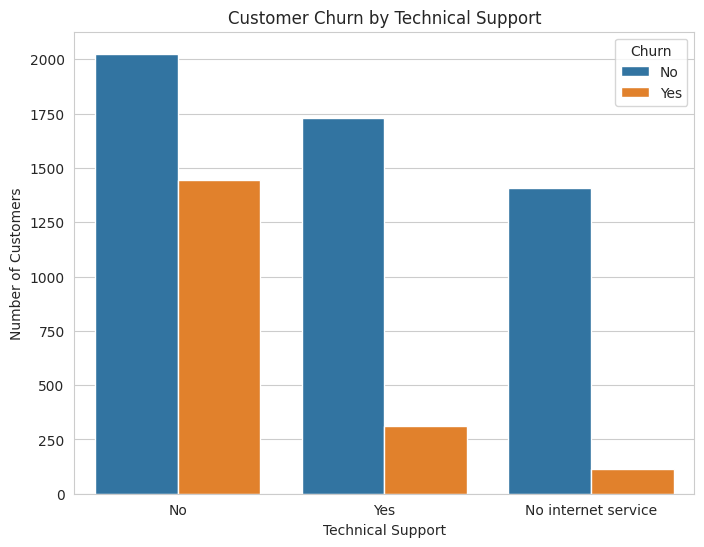

In [28]:
# Customer Churn by Technical Support

plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x='TechSupport',
    hue='Churn'
)

plt.title("Customer Churn by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The analysis shows that customers **without technical support** recorded significantly higher churn than customers who had access to technical support.

Customers receiving technical support demonstrated much stronger retention, suggesting that effective customer assistance contributes to improved customer satisfaction and loyalty.

These findings indicate that expanding technical support services and encouraging customers to subscribe to support packages may help reduce customer churn.